In [ ]:
%pip install opencv-python
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu, threshold_sauvola

In [ ]:
import kagglehub

path = kagglehub.dataset_download("indk214/brain-tumor-dataset-segmentation-and-classification")

print("Dataset Path:", path)

seg_path = f"{path}/DATASET/Segmentation"

print("Segmentation Path: ", seg_path)

classes = ["Glioma", "Meningioma", "Pituitary tumor"]

Dataset Path: /kaggle/input/datasets/indk214/brain-tumor-dataset-segmentation-and-classification
Segmentation Path:  /kaggle/input/datasets/indk214/brain-tumor-dataset-segmentation-and-classification/DATASET/Segmentation


In [ ]:
X=[]
Y=[]
labels=[]

for cls in classes:
    folder = os.path.join(seg_path, cls)

    for f in os.listdir(folder):
        if f.endswith(".png") and "_mask" not in f:
            img_p = os.path.join(folder, f)
            mask_p = os.path.join(folder, f.replace(".png","_mask.png"))
            img = cv2.imread(img_p,0)
            mask = cv2.imread(mask_p,0) 
            mask = (mask > 127).astype(np.uint8) 
            X.append(img)
            Y.append(mask)
            labels.append(cls)

X = np.array(X)
Y = np.array(Y)
labels = np.array(labels)

print(f"Images: {X.shape}, Masks: {Y.shape}, Labels: {labels.shape}")


Images: (2192, 512, 512), Masks: (2192, 512, 512), Labels: (2192,)


In [ ]:
def otsu(img):
    t = threshold_otsu(img)
    return (img > t).astype(np.uint8) 

def sauvola(img, window, k, R=128):
    t = threshold_sauvola(img, window_size=window, k=k, r=R)
    return (img > t).astype(np.uint8)

sauvola_params = {
    "window":[9,25,39,51],
    "k":[0.02,0.03,0.2,0.3,0.5,0.7,1]
}

In [ ]:
EPS = 1e-8 

def dice(y_true, y_pred):
    inter = np.sum(y_true * y_pred)
    return 2*inter / (np.sum(y_true) + np.sum(y_pred) + EPS)

def jaccard(y_true, y_pred):
    inter = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - inter
    return inter / (union + EPS)

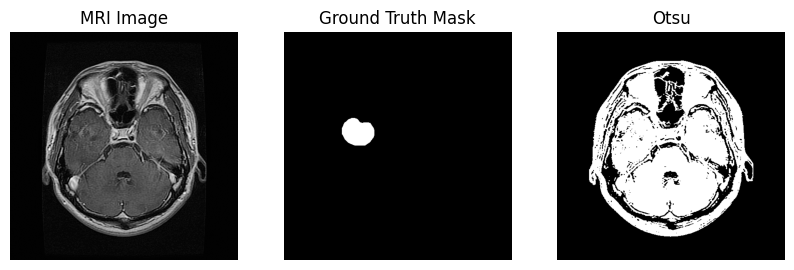

In [32]:
otsu_preds = np.array([otsu(im) for im in X])

idx = 0
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(X[idx], cmap="gray")
plt.title("MRI Image")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(Y[idx], cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(otsu_preds[idx], cmap="gray")
plt.title("Otsu")
plt.axis("off")
plt.show()

In [33]:
otsu_dice = []
otsu_jaccard = []

for i in range(len(Y)):
    otsu_dice.append(dice(Y[i], otsu_preds[i]))
    otsu_jaccard.append(jaccard(Y[i], otsu_preds[i]))

otsu_dice = np.array(otsu_dice)
otsu_jaccard = np.array(otsu_jaccard)

print("Class-wise Evaluation for Otsu: ")

global_dice = []
global_jaccard = []

for cls in np.unique(labels):
    cls_indices = (labels == cls)
    cls_dice = otsu_dice[cls_indices]
    cls_jaccard  = otsu_jaccard[cls_indices]
    global_dice.extend(cls_dice)
    global_jaccard.extend(cls_jaccard)
    print(cls)
    print("Dice:", np.mean(cls_dice))
    print("Jaccard:", np.mean(cls_jaccard))
    print()

print("Evaluation for Otsu, across the dataset:")
print("Dice:", np.mean(global_dice))
print("Jaccard:", np.mean(global_jaccard))

Class-wise Evaluation for Otsu: 
Glioma
Dice: 0.078702263494194
Jaccard: 0.04178770155411961

Meningioma
Dice: 0.06410517878297152
Jaccard: 0.033692552837260026

Pituitary tumor
Dice: 0.048424353639947966
Jaccard: 0.02553030336515117

Evaluation for Otsu, across the dataset:
Dice: 0.06114150065660534
Jaccard: 0.032275500090945694


In [ ]:
results=[]

for w in sauvola_params["window"]:
    for k in sauvola_params["k"]:
        preds = np.array([sauvola(im, window=w, k=k, R=128) for im in X])
        dice_scores=[]
        jaccard_scores=[]
        for i in range(len(Y)):
            dice_scores.append(dice(Y[i], preds[i]))
            jaccard_scores.append(jaccard(Y[i], preds[i])) 
        results.append({
            "window":w,
            "k":k,
            "dice":np.mean(dice_scores),
            "jaccard":np.mean(jaccard_scores)
        }) 

print("Sauvola results with several hyperparameter combinations: ")
count = 1
for r in results:
    print(f"{count}. W={r["window"]}, k={r["k"]} -> dice={r["dice"]}, jaccard={r["jaccard"]}")
    count += 1

Sauvola results with several hyperparameter combinations: 
1. W=9, k=0.02 -> dice=0.029660387951814107, jaccard=0.015178833230840042
2. W=9, k=0.03 -> dice=0.030283974622224197, jaccard=0.015506406389398741
3. W=9, k=0.2 -> dice=0.03438859706816554, jaccard=0.01768603331443823
4. W=9, k=0.3 -> dice=0.03395764698042402, jaccard=0.017461962296921818
5. W=9, k=0.5 -> dice=0.0332354696951833, jaccard=0.01708357769145721
6. W=9, k=0.7 -> dice=0.032716902182792135, jaccard=0.016810983256122364
7. W=9, k=1 -> dice=0.03243652793855051, jaccard=0.01666409017125751
8. W=25, k=0.02 -> dice=0.03114436528355211, jaccard=0.015943308017732992
9. W=25, k=0.03 -> dice=0.03140251625398622, jaccard=0.016080564493718436
10. W=25, k=0.2 -> dice=0.0340568096659543, jaccard=0.017500391158168215
11. W=25, k=0.3 -> dice=0.034092021448502555, jaccard=0.017524165199836517
12. W=25, k=0.5 -> dice=0.03394007736852448, jaccard=0.017450269734279416
13. W=25, k=0.7 -> dice=0.03363065122005657, jaccard=0.0172909720804

In [ ]:
best_dice = max(results, key=lambda x: x["dice"])
best_jaccard = max(results, key=lambda x: x["jaccard"])

print("Best hyperparameters for Sauvola using Dice scores: ")
print(f"W={best_dice["window"]}, k={best_dice["k"]} -> dice={best_dice["dice"]}")

print("Best hyperparameters for Sauvola using Jaccard scores: ")
print(f"W={best_jaccard["window"]}, k={best_jaccard["k"]} -> jaccard={best_jaccard["jaccard"]}") 
sauvola_preds = np.array([sauvola(im, window=best_dice["window"], k=best_dice["k"], R=128) for im in X])

Best hyperparameters for Sauvola using Dice scores: 
W=51, k=0.2 -> dice=0.03514065454222275
Best hyperparameters for Sauvola using Jaccard scores: 
W=51, k=0.2 -> jaccard=0.01806886073734009


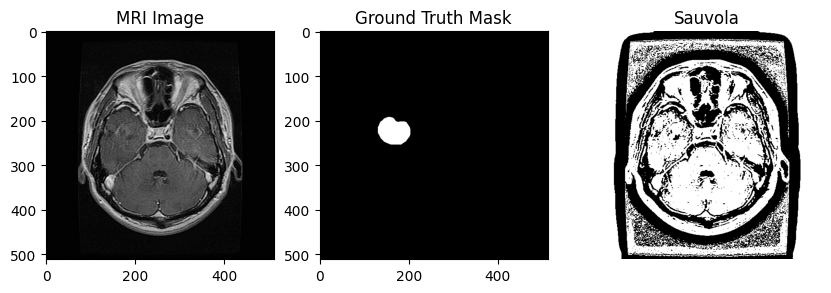

In [ ]:
idx = 0
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(X[idx], cmap="gray")
plt.title("MRI Image")
plt.subplot(1,3,2)
plt.imshow(Y[idx], cmap="gray")
plt.title("Ground Truth Mask")
plt.subplot(1,3,3)
plt.imshow(sauvola_preds[idx], cmap="gray")
plt.title("Sauvola")
plt.axis("off")
plt.show()


In [37]:
sauvola_dice=[]
sauvola_jaccard=[]

for i in range(len(Y)):
    sauvola_dice.append(dice(Y[i], sauvola_preds[i]))
    sauvola_jaccard.append(jaccard(Y[i], sauvola_preds[i]))
    
sauvola_dice=np.array(sauvola_dice)
sauvola_jaccard=np.array(sauvola_jaccard)

print("Class-wise Evaluation for Sauvola: ")

global_dice = []
global_jaccard = []

for cls in np.unique(labels):
    cls_indices = (labels == cls)
    cls_dice = sauvola_dice[cls_indices]
    cls_jaccard  = sauvola_jaccard[cls_indices]
    global_dice.extend(cls_dice)
    global_jaccard.extend(cls_jaccard)
    print(cls)
    print("Dice:", np.mean(cls_dice))
    print("Jaccard:", np.mean(cls_jaccard))
    print()

print("Evaluation for Sauvola, across the dataset:")
print("Dice:", np.mean(global_dice))
print("Jaccard:", np.mean(global_jaccard))

Class-wise Evaluation for Sauvola: 
Glioma
Dice: 0.040291111777353374
Jaccard: 0.020771603994171065

Meningioma
Dice: 0.03901740818394248
Jaccard: 0.020080377065652678

Pituitary tumor
Dice: 0.029121197674911007
Jaccard: 0.014927491570964109

Evaluation for Sauvola, across the dataset:
Dice: 0.03514065454222275
Jaccard: 0.01806886073734009
